# What do we do here? 
- Get data from Tiingo
- Use linear regression slope of multiple timeframes to determine every instrument's trend.
  Across every timeframe, we use -1 for a negative trend and +1 for a positive one to account for
  the steeper slopes of shorter timeframes. We then use the mean across those -1/1 values to
  determine the trend.
- Pass all instrument with positive trends to the Ledoit-Wolf algorithm to determine the weights.
  We use Ledoit Wolf (that simplifies covariance estimation) and optimize for maximum
  diversification.
- We average the trends; this results in a number between -1 and 1; we adjust it to go from 0 to 1 
  which gies us the target exposure; we then multiply our weights by it to get the adjusted weights.

  We could go weekly with trend [20, 30, 40, 50, 60] and 30 lookback for Ledoit-Wolf.

In [44]:
%reload_ext autoreload
%autoreload 2

import tiingo_fetcher
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import data_splitter
import backtest
import ledoit_wolf
from datetime import date
from dotenv import load_dotenv
import regression
import os

# Make charts interactive
# %matplotlib widget

In [45]:
load_dotenv()
api_key = os.getenv('TIINGO_API_KEY')

# Separate block so that we don't need to re-fetch data every time we update something
# If we don't pass date, a (cached, old) date will be used
# etf_data = tiingo_fetcher.fetch_data(['SSO', 'UGL', 'TMF', 'TMV', 'TYD', 'SPY', 'GLD', 'TLT', 
#   'IEF', 'BIL', 'URE', 'VXUS', 'BNDX', 'UPRO', 'UDOW', 'URTY', 'AGQ', 'DDM', 'UWM', 'UBT', 'UST',
#   'SPXL', 'FTF', 'TYO', 'EDC', 'GLL', 'TQQQ', 'YINN'], end=date.today()) 
etf_data = tiingo_fetcher.fetch_data(api_key, ['UPRO', 'UGL', 'TMF', 'TMV'], end=date.today()) 

# future_instruments = instruments = [
#   'FV2', # 5 yr note
#   # Data only from 2010 onwards
#   # 'US2', # U.S. Ultra T-Bond C	
#   'ES', # sp500
#   'GBS', # euro schatz
#   'LFT', # ftse100 (quite negatively correlating to everything)
#   'SXF', # sp60 canada
#   'BC', # crude oil
#   # Fetching that returns only data after 2017
#   # 'EUA', # carbon dioxide certificate - only starts in 2017
#   'GC2', # gold
#   'UL2', # U.S. Ultra T-Bond C	
#   'SB2', # sugar
#   'RTY', # russell 2000
#   'C2', # corn
#   'EC', # euro fx
# ]
# futures_data = data_fetcher.get_data(future_instruments)

Get data for ['UPRO', 'UGL', 'TMF', 'TMV'], from 1990-01-01 to 2025-11-05
Got data for UPRO from 2009-06-25 to 2025-11-04
Got data for UGL from 2008-12-03 to 2025-11-04
Got data for TMF from 2009-04-16 to 2025-11-04
Got data for TMV from 2009-04-16 to 2025-11-04
Returning a DataFrame of 4×4257


Latest data
              UPRO    UGL    TMF    TMV
date                                   
2025-10-29  120.91  47.38  42.57  33.10
2025-10-30  117.03  49.25  41.86  33.64
2025-10-31  117.94  48.68  41.41  33.95
2025-11-03  118.68  48.94  41.06  34.30
2025-11-04  114.46  47.15  41.36  34.05


<Axes: xlabel='date'>

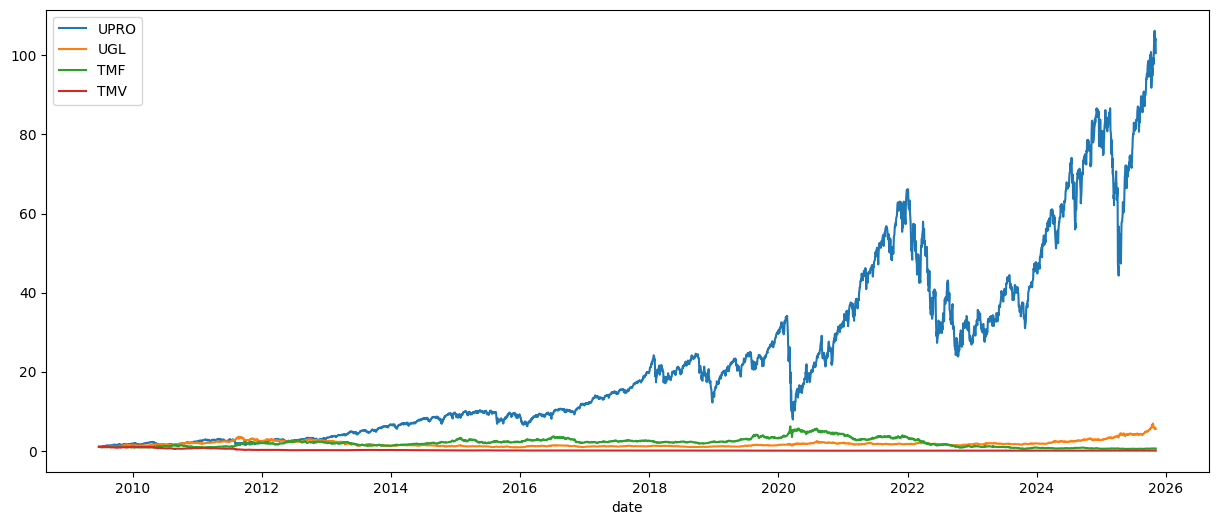

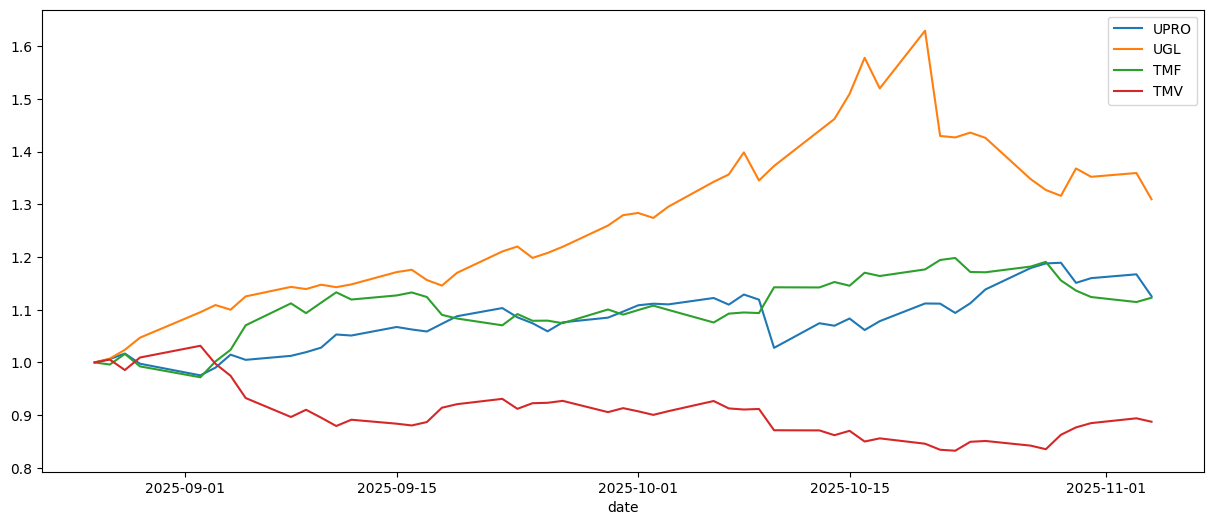

In [46]:
# Limit data (debug / devlop)
data = etf_data.iloc[0:]

# double_instruments_all = ['SSO', 'UGL', 'TMF', 'TYD', 'UBT', 'AGQ', 'DDM', 'UWM']  
# 13%/-31%; UGL does not exist in 3x
# Adding GLL improves KPIs, but lowers return to 8.5%
triple_instruments = ['UPRO', 'UGL', 'TMF', 'TMV']
# wide_triple_instruments = ['UPRO', 'UGL', 'TMF', 'TMV', 'TQQQ', 'UDOW', 'YINN', 'URTY']
# Use the same as single instruments to get a more extended view
single_instruments = ['SPY', 'GLD', 'TLT']
# double_instruments = ['SSO', 'UGL', 'UBT', 'UST']
# double_instruments_plus_bil = ['SSO', 'UGL', 'TMF', 'TYD', 'BIL'] 
# triple_instruments = ['UPRO', 'UDOW', 'URTY', 'TMF', 'TYD']
# single_instruments_many = ['SPY', 'GLD', 'TLT', 'IEF', 'BIL', 'VXUS', 'BNDX']
# single_instruments = ['SPY', 'GLD', 'TLT']

data = data[triple_instruments]
# data = data.loc['2010-01-01':]
# data = data.loc[:'2020-01-01']
# data = futures_data[['ES', 'UL2', 'GC2', 'FV2']]

print('Latest data')
print(data.tail(5))

# Only drop data *after* selecting instruments (or we will drop too much) 
data = data.dropna()

relative_closes = data / data.iloc[0]
relative_closes.plot(figsize=(15, 6))

latest_closes = data.iloc[-50:]
latest_relative_closes = latest_closes / latest_closes.iloc[0]
latest_relative_closes.plot(figsize=(15, 6))


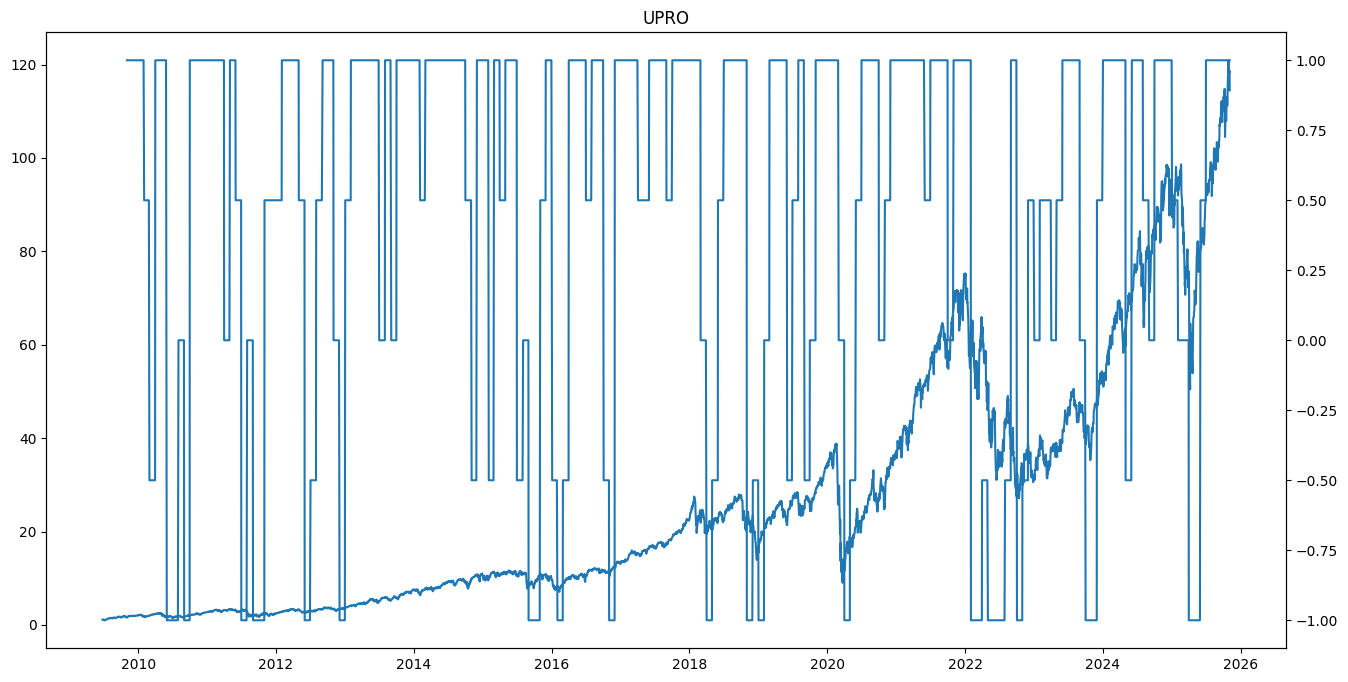

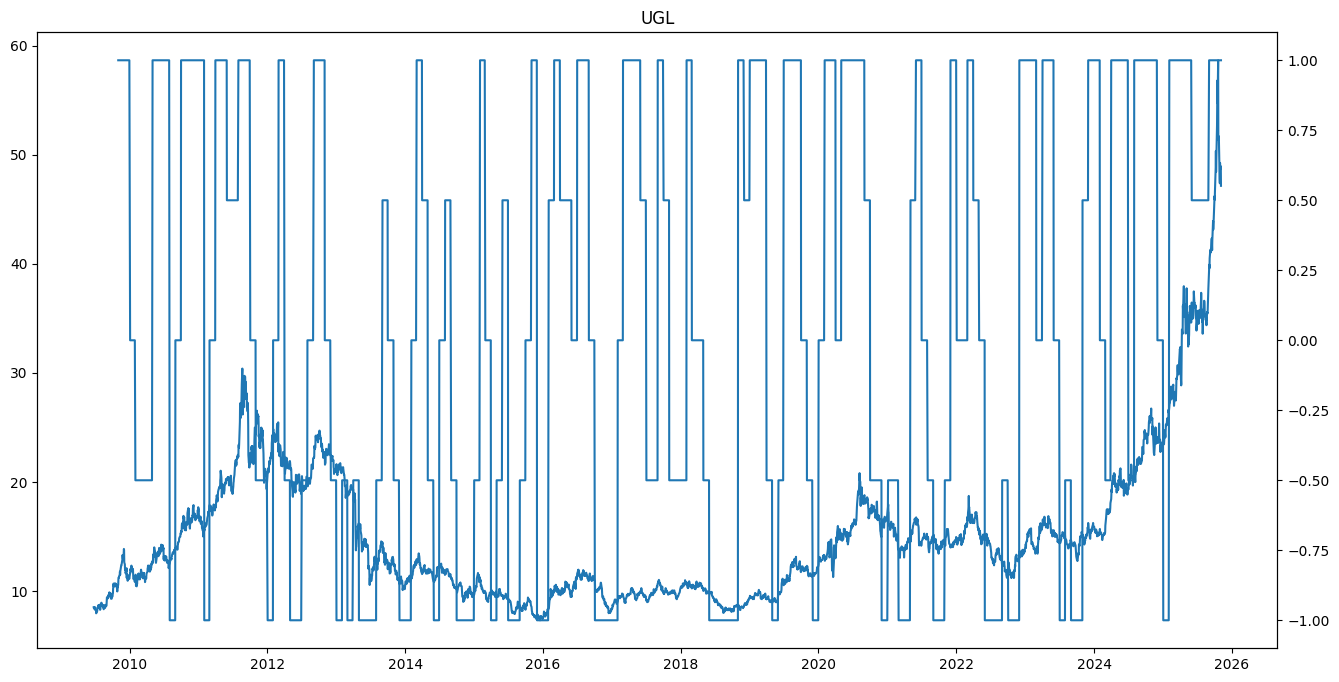

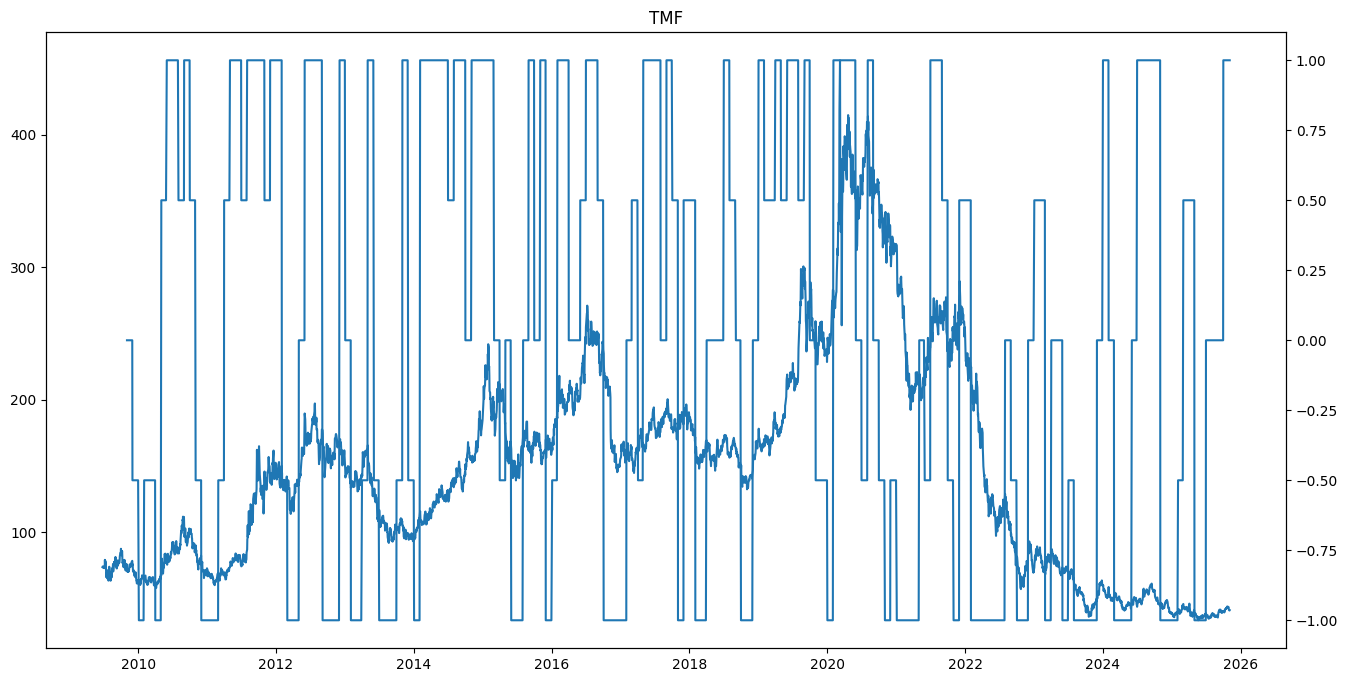

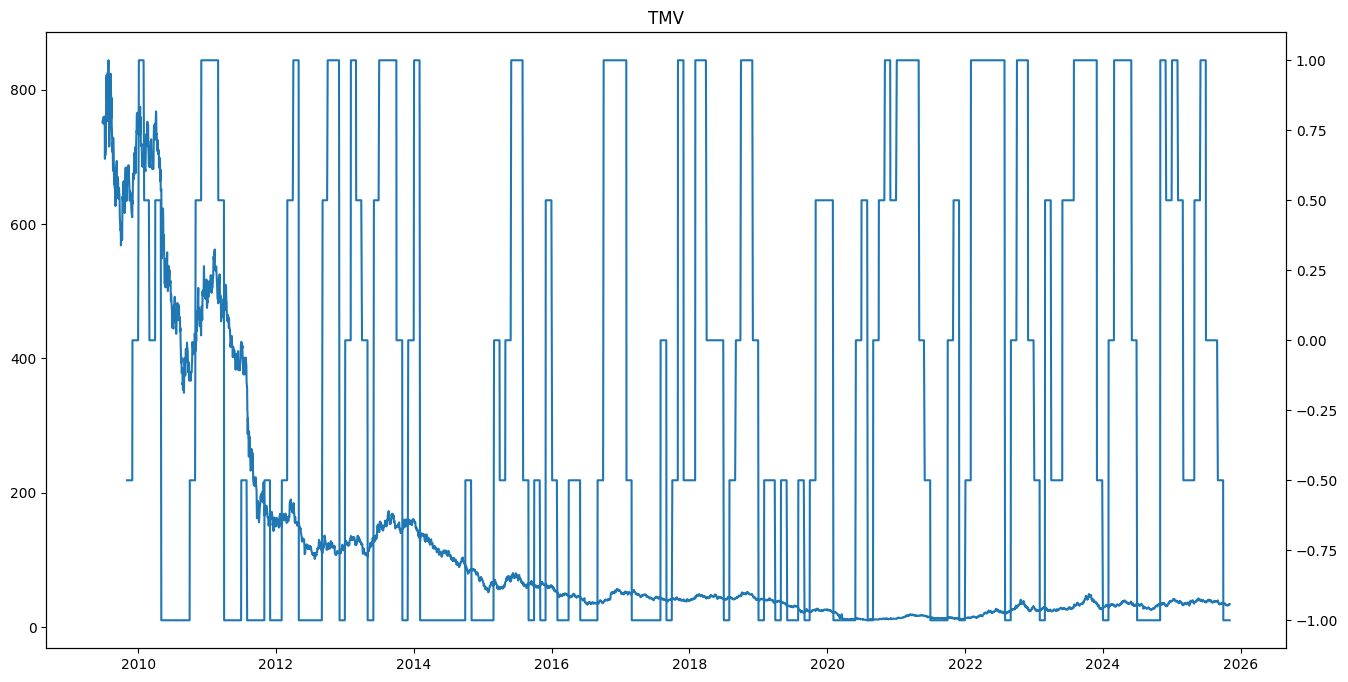

In [47]:
time_blocks = data_splitter.split_data(data, interval='month', min_segment_duration=pd.Timedelta(days=100))

trend_list = []
trend_timeframes = [40, 60, 80, 100]
# trend_timeframes = [20, 30, 40, 50, 60]
for block in time_blocks:
  end_date = block.index[-1]
  current_time_blocks = [block[end_date - pd.Timedelta(days=i):end_date] for i in trend_timeframes]
  block_trends_list = [regression.get_relative_slope(block) for block in current_time_blocks]
  block_trends = pd.concat(block_trends_list, axis=1)
  block_trends.columns = trend_timeframes
  # Shorter timeframes have more extreme slopes; adjust by multiplying the values with
  # the timeframe's length; just use positive or negative values to remove the slope
  block_trends[block_trends < 0] = -1
  block_trends[block_trends > 0] = 1
  block_trend_average = block_trends.mean(axis=1)
  trend_list.append(pd.Series(block_trend_average, index=block.columns, name=end_date))

trend = pd.concat(trend_list, axis=1).T

# Just print the instruments
instruments = trend.columns
for instrument in instruments:
  instrument_data = pd.DataFrame({
    'trend': trend[instrument],
    'data': data[instrument]
  })
  # We only get trends for the first day of the month; every other day will be NaN. Use the previous
  # value for all subsequent days of the month.
  instrument_data['trend'] = instrument_data['trend'].ffill()
  fig, ax1 = plt.subplots(figsize=(16, 8))
  ax1.plot(instrument_data.data)
  ax2 = ax1.twinx()
  ax2.plot(instrument_data.trend)
  plt.title(instrument)
  plt.show()

# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 8))
# ax1.plot(relative_closes.index, relative_closes['SSO'])
# ax2.bar(trend.index, trend['SSO'], width=20)

In [48]:
# # This is just here to test the trend filter
# fixed_weights = trend.copy()
# fixed_weights['SSO'] = 0.3
# fixed_weights['TMF'] = 0.3
# fixed_weights['TYD'] = 0.2
# fixed_weights['UGL'] = 0.2
# fixed_weights = fixed_weights[trend > 0]
# result = backtest.run('trend_filter', data, fixed_weights)
# result.display()
# result.plot()

Data for Ledoit Wolf
                UPRO        UGL
date                           
2009-09-03  1.453313   9.410125
2009-09-04  1.516900   9.437500
2009-09-08  1.556756   9.405000
2009-09-09  1.593335   9.332500
2009-09-10  1.641844   9.449300
2009-09-11  1.639484   9.645000
2009-09-14  1.667148   9.494975
2009-09-15  1.686158   9.677500
2009-09-16  1.761020   9.877500
2009-09-17  1.752629   9.762500
2009-09-18  1.757742   9.640000
2009-09-21  1.742927   9.565000
2009-09-22  1.775704   9.800000
2009-09-23  1.728112   9.637525
2009-09-24  1.672303   9.385000
2009-09-25  1.646592   9.288500
2009-09-28  1.732380   9.295000
2009-09-29  1.722542   9.350000
2009-09-30  1.699849   9.632500
2009-10-01  1.571301   9.450000
2009-10-02  1.553856   9.532500
2009-10-05  1.618785   9.821500
2009-10-06  1.690012  10.292500
2009-10-07  1.702945  10.325000
2009-10-08  1.744185  10.675000
2009-10-09  1.772125  10.420000
2009-10-12  1.794949  10.562500
2009-10-13  1.785373  10.695000
2009-10-14  1.87614

<Axes: >

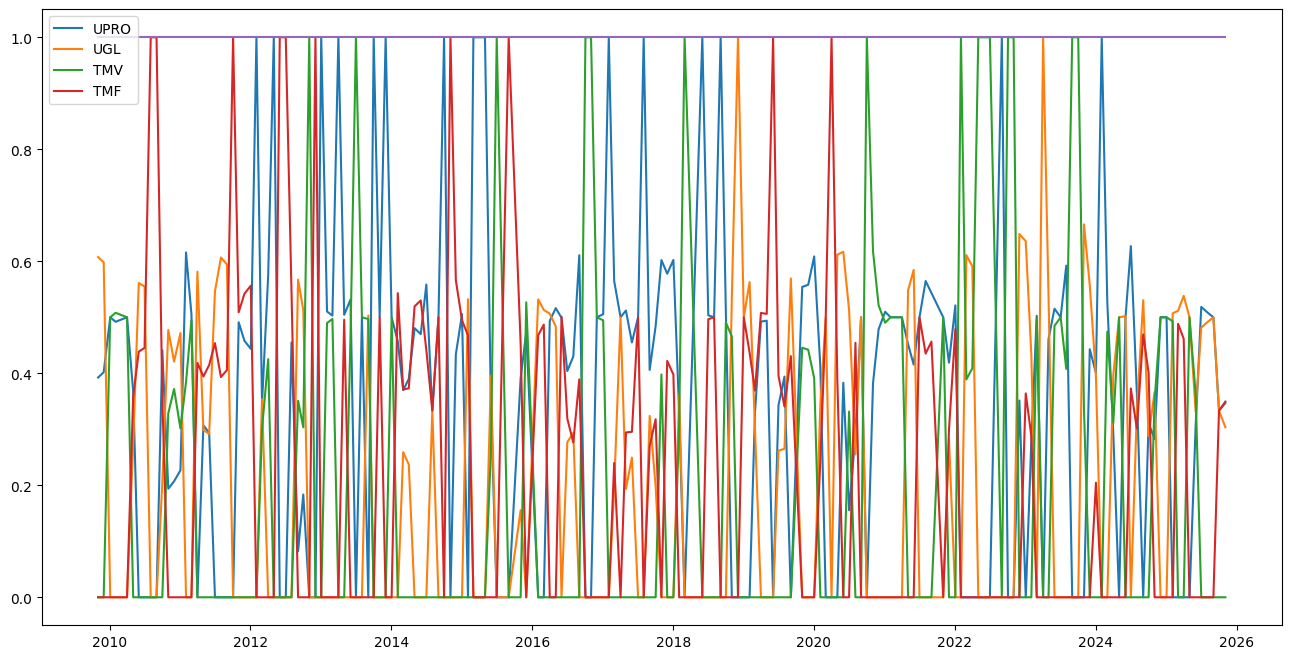

In [49]:
weight_list = []
# Get the Ledoit Wolf weights; only use the instruments that have a positive trend, discard the
# rest *before* calculating the weights (Ledoit Wolf uses covariance; passing in unused instruments
# would invalidate the matrix to some extent)
for block in time_blocks:
    end_date = block.index[-1]
    # Only use last x days (every block gets longer)
    current_block = block[end_date - pd.Timedelta(days=60):end_date]
    # Only pass thrending instruments to Ledoit Wolf
    current_trends = trend.loc[end_date]
    instruments_with_uptrend = current_trends[current_trends > 0].index.values
    current_block_with_uptrend = current_block[instruments_with_uptrend]
    if instruments_with_uptrend.size == 0:
        continue
    print('Data for Ledoit Wolf')
    print(current_block_with_uptrend)
    weights = ledoit_wolf.calculate_weights(current_block_with_uptrend)
    # weights = ledoit_wolf.calculate_weights(current_block)
    series = pd.Series(weights, index=current_block_with_uptrend.columns, name=current_block.index[-1])
    weight_list.append(series)

weights = pd.concat(weight_list, axis=1).T
weights = weights.fillna(0)

# Test equal weights 
# weights[:] = 1 / len(data.columns)
# weights[trend < 0] = 0
# weights = weights.mul(1 / weights.sum(axis = 1), axis = 0)

weights.plot(figsize=(16, 8))
weights.sum(axis = 1).plot()

Adjusted Weights:
UPRO    26.0%
UGL     22.8%
TMV      0.0%
TMF     26.2%
---
Latest Quotes:
UPRO    114.46
UGL      47.15
TMF      41.36
TMV      34.05
---
Distribution:
UPRO    31737.0
UGL     27792.0
TMV         0.0
TMF     31970.0
---
Positions:
TMF     772.0
TMV       0.0
UGL     589.0
UPRO    277.0
---
                UPRO       UGL  TMV       TMF
2025-07-01  0.356501  0.330999  0.0  0.000000
2025-08-01  0.349888  0.337612  0.0  0.000000
2025-09-02  0.343750  0.343750  0.0  0.000000
2025-10-01  0.250000  0.250000  0.0  0.250000
2025-11-03  0.260142  0.227807  0.0  0.262051


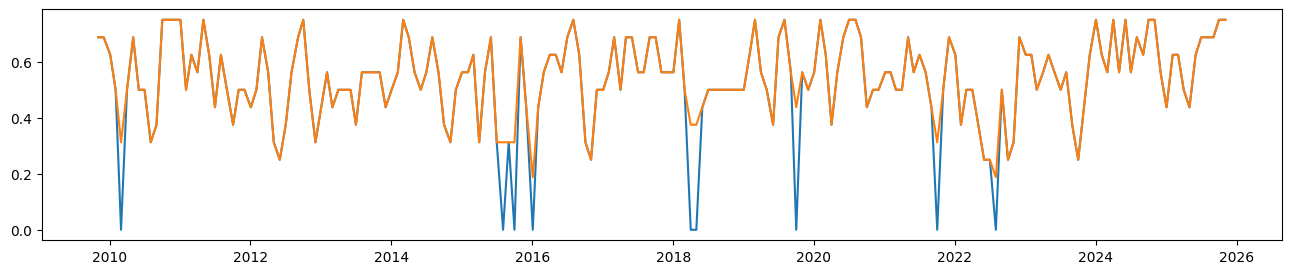

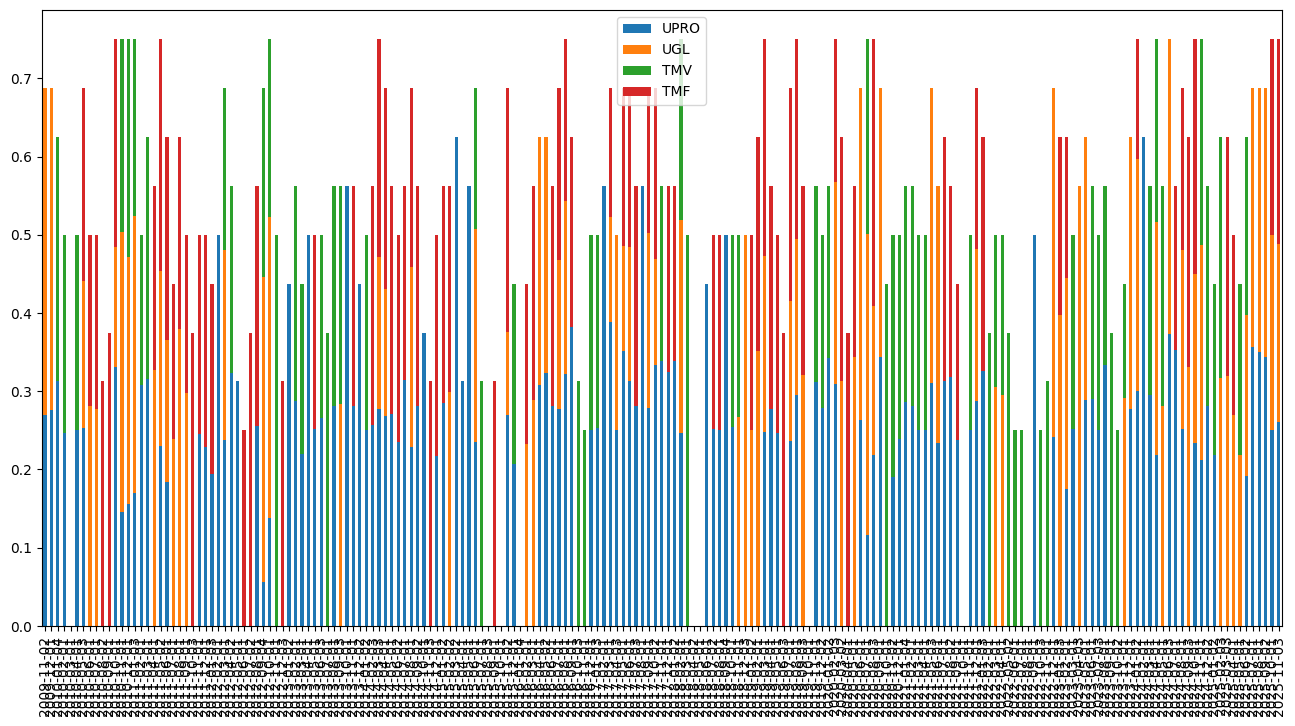

In [50]:
# Trends' mean flucutates between -1 (all negative) and 1 (all positive); adjust to go from 0 to 1
max_exposition = (trend.mean(axis=1) + 1) / 2
# Go long and short
# max_exposition = trend.mean(axis=1)
# Limit max expsoition
# max_exposition[max_exposition > 0.6] = 0.6
adjusted_weights = weights.mul(max_exposition, axis=0)

print('Adjusted Weights:')
formatted = series.apply(lambda x: f"{x * 100:.2f}%")
print(adjusted_weights.iloc[-1].apply(lambda x: f'{x * 100:.1f}%').to_string()) 
print('---')
account_value = 122000
latest_quote = data.iloc[-1]
print('Latest Quotes:')
print(latest_quote.to_string())
print('---')
distribution = account_value * adjusted_weights.iloc[-1]
print('Distribution:')
print(distribution.apply(np.floor).to_string())
print('---')
print('Positions:')
print((distribution / latest_quote).apply(np.floor).to_string())
print('---')

adjusted_weights.sum(axis=1).plot(figsize=(16, 3))
max_exposition.plot()
adjusted_weights.plot(kind='bar', stacked=True, figsize=(16, 8))

print(adjusted_weights.iloc[-5:])

100%|██████████| 1/1 [00:00<00:00,  4.45it/s]

Stat                 ledoit_wolf
-------------------  -------------
Start                2009-06-24
End                  2025-11-04
Risk-free rate       0.00%

Total Return         580.45%
Daily Sharpe         0.80
Daily Sortino        1.27
CAGR                 12.43%
Max Drawdown         -28.55%
Calmar Ratio         0.44

MTD                  -1.48%
3m                   17.41%
6m                   24.14%
YTD                  24.77%
1Y                   29.76%
3Y (ann.)            18.88%
5Y (ann.)            16.17%
10Y (ann.)           14.87%
Since Incep. (ann.)  12.43%

Daily Sharpe         0.80
Daily Sortino        1.27
Daily Mean (ann.)    13.08%
Daily Vol (ann.)     16.34%
Daily Skew           -0.40
Daily Kurt           4.80
Best Day             6.90%
Worst Day            -7.30%

Monthly Sharpe       0.88
Monthly Sortino      1.77
Monthly Mean (ann.)  12.76%
Monthly Vol (ann.)   14.43%
Monthly Skew         0.15
Monthly Kurt         1.15
Best Month           15.97%
Worst Month      

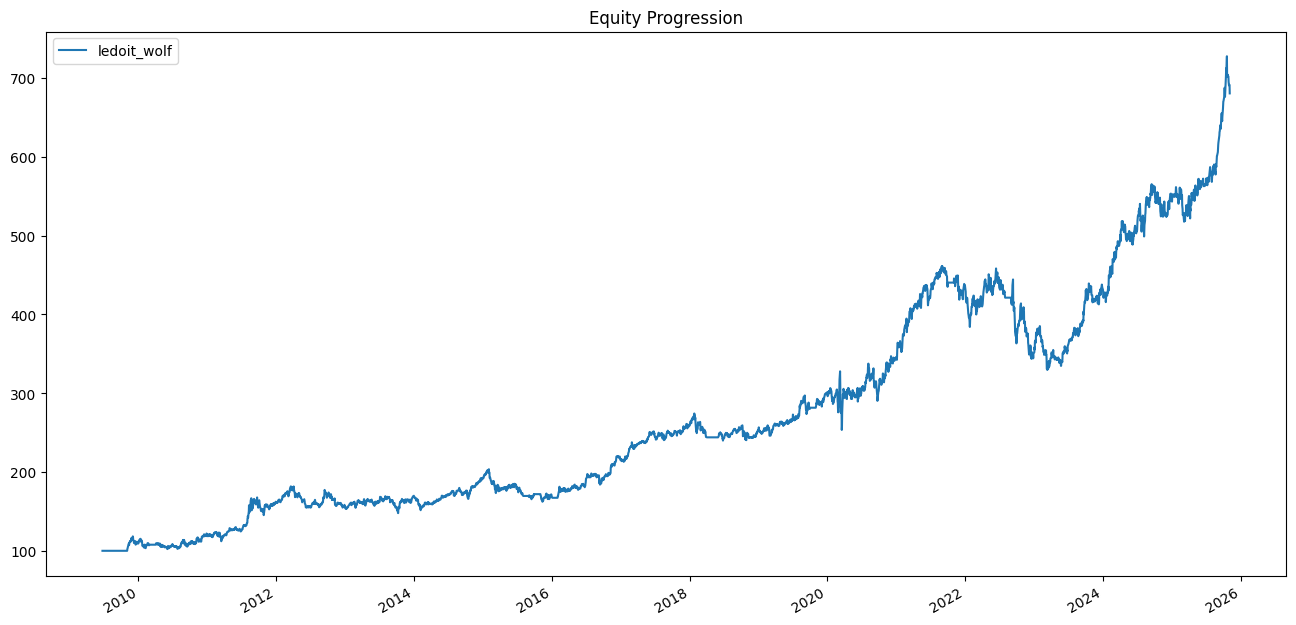

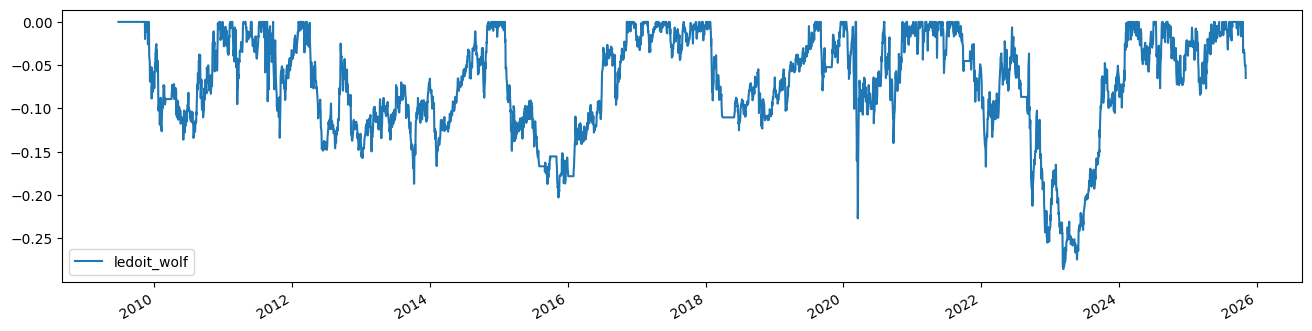

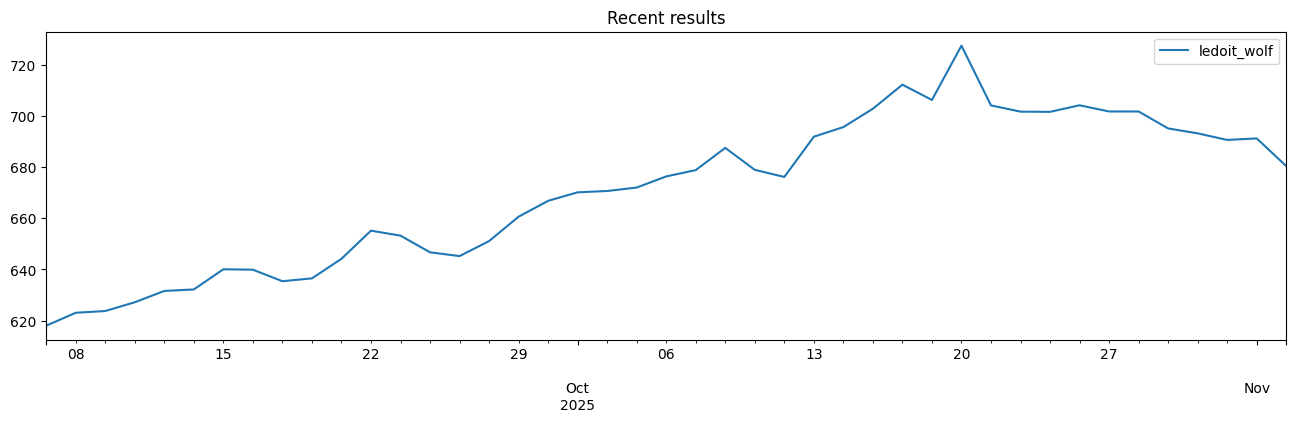

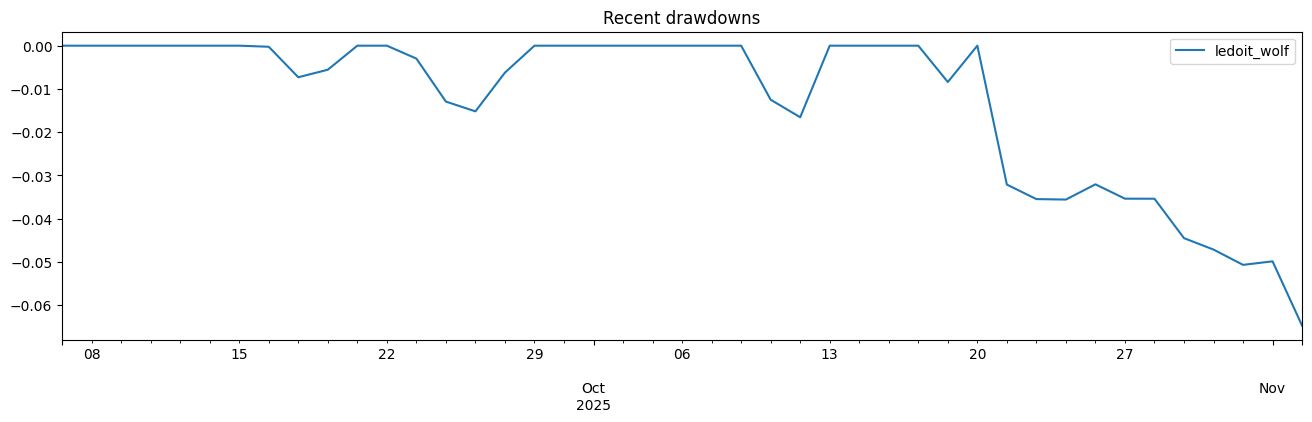

In [51]:
# bt needs dates as datetimes
data.index = pd.to_datetime(data.index)
adjusted_weights.index = pd.to_datetime(adjusted_weights.index)

result = backtest.run('ledoit_wolf', data, adjusted_weights)

result.display()
result.plot(figsize=(16, 8))

# Let's display how we should have done in the past month (just to check reality vs. strategy)
first_of_month = result.prices.groupby(result.prices.index.to_period('M')).head(1)
first_of_month_and_previous = pd.DataFrame(first_of_month)
first_of_month_and_previous['PreviousMonth'] = first_of_month_and_previous.shift(1)
for index, row in first_of_month_and_previous.iterrows():
  print(f'{index.date()}, {(row['ledoit_wolf'] / row['PreviousMonth']) * 100 - 100:.2f}%') 

rolling_max = result.prices.cummax()
drawdowns = (result.prices - rolling_max) / rolling_max
drawdowns.plot(figsize=(16, 4))
plt.show()

recent_results = result.prices.loc[result.prices.index[-1] - pd.Timedelta(days=(60)):]
recent_results.plot(figsize=(16, 4), title='Recent results')
recent_rolling_max = recent_results.cummax()
recent_drawdowns = (recent_results - recent_rolling_max) / recent_rolling_max
recent_drawdowns.plot(figsize=(16, 4), title='Recent drawdowns')
plt.show()